In [76]:
%load_ext autoreload
%autoreload 2

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import h5py
import os
from multiprocess import Pool
import importlib
from tqdm.auto import tqdm
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../../")
import pyanalib.pandas_helpers as ph
from makedf.util import *

workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../")
import kinematics
import gump_cuts as gc
import loaddf
import syst

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
RECO = "PANDORA"
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [48]:
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-7/"

SCV_FILES = [DF_DIR + "SBND_SpringMC_rewgt_E_%i.df" % i for i in range(20)]
SDIRT_FILE = DF_DIR + "SBND_SpringLowEMC.df"
SBEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData_5000.df"

SDETVAR_FILES = [
    [DF_DIR + "SBND_SpringMC_rewgt_E_%i.df" % i for i in range(20)],
    [DF_DIR + "SBND_SpringMC_BigWMXThetaXW_%i.df" % i for i in range(10)],
    [DF_DIR + "SBND_SpringMC_BigWMYZ_%i.df" % i for i in range(10)],
]
# SDETVAR_FILES = [
#     [DF_DIR + "SBND_SpringMC_Nom.df"],
#     [DF_DIR + "SBND_SpringMC_WMXThetaXW.df"],
#     [DF_DIR + "SBND_SpringMC_WMYZ.df"],
# ]

SDETVAR_NAMES = ["Nominal",
                 "WM $X\\theta_{xw}$", "WM $YZ$", 
                 ]

SDETVAR_FILES_SMALL = [
    DF_DIR + "SBND_SpringMC_Nom.df",
    DF_DIR + "SBND_SpringMC_2xSCE.df",
]

SDETVAR_NAMES_SMALL = ["Nominal", "2xSCE"]

IRUN2_CV_FILES = [DF_DIR + "ICARUS_SpringMCOverlay_rewgt.df"]
IRUN4_CV_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]
IRUN2_DIRT_FILES = [DF_DIR + "ICARUS_Spring_Overlay_Dirt.df"]
IRUN4_DIRT_FILES = [DF_DIR + "ICARUSRun4_Spring_Overlay_Dirt.df"]
IRUN2_BEAMOFF_FILES = [DF_DIR.replace('7', '6').replace('gputnam', 'nrowe') + "ICARUSRun2_BNBoff_uncalo_unblind_%i.df" % i for i in range(60)]
IRUN4_BEAMOFF_FILES = [DF_DIR.replace('7', '6').replace('gputnam', 'nrowe') + "ICARUSRun4_BNBoff_%i.df" % i for i in range(60)]
IRUN2_DETVAR_FILES = [[DF_DIR + "ICARUS_SpringMCOverlay_rewgt.df"],
                      [DF_DIR + "ICARUS_Spring_WMLooseXTHXW.df"],
                      [DF_DIR + "ICARUS_Spring_SCE.df"]]

IRUN4_DETVAR_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_0.df",
                      DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_0.df",
                      DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_0.df"]

IDETVAR_NAMES = ["Nominal", 
                 "WM $X\\theta_{xw}$",
                 "SCE"]

IRUN2_POT = 2e20
IRUN4_POT = 3e20
IGOAL_POT = IRUN2_POT + IRUN4_POT
SGOAL_POT = 1e20

In [49]:
%%capture
# Load Run 2 and Run 4 ICARUS MC separately
Idf_r2, Imatch_r2, Ipot_r2 = loaddf.loadl(IRUN2_CV_FILES, njob=min(len(IRUN2_CV_FILES), 20), detector="ICARUS Run2", 
                                 preselection=gc.presel_cut, reweight_aFF=True, drops=loaddf.get_std_drops(), lightmem=True)
# Scale each run to its target POT before combining
loaddf.scale_pot(Idf_r2, Ipot_r2, IRUN2_POT)

# Load Run 2 and Run 4 ICARUS dirt separately
if len(IRUN2_DIRT_FILES) > 0:
    Idirt_r2, Idirtmatch_r2, Idirtpot_r2 = loaddf.loadl(IRUN2_DIRT_FILES, njob=min(len(IRUN2_DIRT_FILES), 20), detector="ICARUS Run2", 
                                               preselection=gc.presel_cut, include_syst=False, drops=loaddf.get_std_drops(), lightmem=True)
    loaddf.scale_pot(Idirt_r2, Idirtpot_r2, IRUN2_POT)

# Load Run 2 and Run 4 ICARUS beamoff separately
Ioffbeam_r2, _, Ioffbeampot_r2 = loaddf.loadl(IRUN2_BEAMOFF_FILES, detector="ICARUS Run2", offbeampot=True, 
                                                   preselection=gc.presel_cut, include_syst=False, load_truth=False, match_Enu = False, drops=loaddf.get_std_drops(), lightmem=True)
loaddf.scale_pot(Ioffbeam_r2, Ioffbeampot_r2, IRUN2_POT)

In [50]:
Idetvars_r2, Idetvarsmatch_r2, Idetvar_pots_r2 = zip(*tqdm([loaddf.loadl(f, preselection=gc.presel_cut, include_syst=False, detector="ICARUS Run2", njob=min(len(f), 20)) for f in IRUN2_DETVAR_FILES]))

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUS_SpringMCOverlay_rewgt.df idf=0] dedup: dropped 3861 duplicated ('run', 'evt', 'nu_E0') keys (7722 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=5] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=6] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=7] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringMCOverlay_rewgt.df idf=8] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICA

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUS_Spring_WMLooseXTHXW.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=5] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=6] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=7] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.df idf=8] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_WMLooseXTHXW.

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUS_Spring_SCE.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=5] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=6] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=7] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=8] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Spring_SCE.df idf=9] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_Sp

  0%|          | 0/3 [00:00<?, ?it/s]

In [51]:
%%capture
Idf_r4, Imatch_r4, Ipot_r4 = loaddf.loadl(IRUN4_CV_FILES, njob=min(len(IRUN4_CV_FILES), 20), detector="ICARUS Run4", 
                                 preselection=gc.presel_cut, reweight_aFF=True, drops=loaddf.get_std_drops(), lightmem=True)

# Scale each run to its target POT before combining
loaddf.scale_pot(Idf_r4, Ipot_r4, IRUN4_POT)

# Load Run 2 and Run 4 ICARUS dirt separately
if len(IRUN4_DIRT_FILES) > 0:
    Idirt_r4, Idirtmatch_r4, Idirtpot_r4 = loaddf.loadl(IRUN4_DIRT_FILES, njob=min(len(IRUN4_DIRT_FILES), 20), detector="ICARUS Run4", 
                                               preselection=gc.presel_cut, include_syst=False, drops=loaddf.get_std_drops(), lightmem=True)
    loaddf.scale_pot(Idirt_r4, Idirtpot_r4, IRUN4_POT)

Ioffbeam_r4, _, Ioffbeampot_r4 = loaddf.loadl(IRUN4_BEAMOFF_FILES, detector="ICARUS Run4", offbeampot=True, 
                                                   preselection=gc.presel_cut, include_syst=False, load_truth=False, match_Enu = False, drops=loaddf.get_std_drops(), lightmem=True)
loaddf.scale_pot(Ioffbeam_r4, Ioffbeampot_r4, IRUN4_POT)

In [52]:
Idetvars_r4, Idetvarsmatch_r4, Idetvar_pots_r4 = zip(*tqdm([loaddf.load(f, preselection=gc.presel_cut, include_syst=False, detector="ICARUS Run4") for f in IRUN4_DETVAR_FILES]))

[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=5] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=6] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=1] dedup: dropped 0 duplicate

  0%|          | 0/3 [00:00<?, ?it/s]

In [53]:
%%capture
Sdf, Smatch, Spot = loaddf.loadl(SCV_FILES, njob=min(len(SCV_FILES), 20), detector="SBND",
                                 preselection=gc.presel_cut, reweight_aFF=True, drops=loaddf.get_std_drops(), lightmem=True)
Sdirt, Sdirtmatch, Sdirtpot = loaddf.load(SDIRT_FILE, detector="SBND",
                                          preselection=gc.presel_cut, include_syst=False, drops=loaddf.get_std_drops(), lightmem=True)
Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(SBEAMOFF_FILE, detector="SBND",
                                                   preselection=gc.presel_cut, offbeampot=True, include_syst=False, load_truth=False, drops=loaddf.get_std_drops(), lightmem=True)

In [54]:
Sdetvars_small, Sdetvarsmatch_small, Sdetvar_pots_small = zip(*tqdm([loaddf.load(f, preselection=gc.presel_cut, include_syst=False, detector="SBND") for f in SDETVAR_FILES_SMALL]))
Sdetvars, Sdetvarsmatch, Sdetvar_pots = zip(*tqdm([loaddf.loadl(f, preselection=gc.presel_cut, include_syst=False, detector="SBND", njob=min(len(f), 20)) for f in SDETVAR_FILES]))
# Sdetvars = (Sdf,) + Sdetvars
# Sdetvarsmatch = (Smatch,) + Sdetvarsmatch
# Sdetvar_pots = (Spot,) + Sdetvar_pots

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringMC_Nom.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringMC_Nom.df idf=1] dedup: dropped 1 duplicated ('run', 'evt', 'nu_E0') keys (2 hdr rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:469: RuntimeWarning: invalid value encountered in subtract
  direction = p2 - p1
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


...

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringMC_BigWMYZ_5.df] cross-idf dedup: dropped 1499 duplicated ('run', 'evt', 'nu_E0') keys (2998 match rows)


/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:484: RuntimeWarning: invalid value encountered in subtract
  tmin = (p_min[i] - p1[:, i]) * inv_dir
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:485: RuntimeWarning: invalid value encountered in subtract
  tmax = (p_max[i] - p1[:, i]) * inv_dir


[SBND_SpringMC_BigWMYZ_6.df idf=4] dedup: dropped 50 duplicated ('run', 'evt', 'nu_E0') keys (100 hdr rows)
[SBND_SpringMC_BigWMYZ_1.df] cross-idf dedup: dropped 1678 duplicated ('run', 'evt', 'nu_E0') keys (3356 match rows)
[SBND_SpringMC_BigWMYZ_4.df idf=4] dedup: dropped 17 duplicated ('run', 'evt', 'nu_E0') keys (34 hdr rows)
[SBND_SpringMC_BigWMYZ_0.df idf=4] dedup: dropped 54 duplicated ('run', 'evt', 'nu_E0') keys (108 hdr rows)
[SBND_SpringMC_BigWMYZ_6.df] cross-idf dedup: dropped 1825 duplicated ('run', 'evt', 'nu_E0') keys (3650 match rows)
[SBND_SpringMC_BigWMYZ_4.df] cross-idf dedup: dropped 1486 duplicated ('run', 'evt', 'nu_E0') keys (2972 match rows)
[SBND_SpringMC_BigWMYZ_0.df] cross-idf dedup: dropped 1477 duplicated ('run', 'evt', 'nu_E0') keys (2954 match rows)
dedup: dropped 1620860 duplicated rows 1.0 of the POT remaining. Before POT: 6.21578165214142e+20, after POT 6.21578165214142e+20.


  0%|          | 0/3 [00:00<?, ?it/s]

In [55]:
Idf = pd.concat([Idf_r2, Idf_r4]).reset_index(drop=True)
Imatch = pd.concat([Imatch_r2, Imatch_r4])
Ipot = IRUN2_POT + IRUN4_POT

# Load Run 2 and Run 4 ICARUS dirt separately
if len(IRUN2_DIRT_FILES) > 0 and len(IRUN4_DIRT_FILES) > 0:
    Idirt = pd.concat([Idirt_r2, Idirt_r4]).reset_index(drop=True)
else:
    Idirt = pd.DataFrame(columns=Idf.columns)
Idirtpot = IRUN2_POT + IRUN4_POT
Ioffbeam = pd.concat([Ioffbeam_r2, Ioffbeam_r4]).reset_index(drop=True)
Ioffbeampot = IRUN2_POT + IRUN4_POT

Idetvars_r2, Idetvar_pots_r2 = loaddf.match_common_evts(Idetvarsmatch_r2, Idetvars_r2, Idetvar_pots_r2)
Idetvars_r4, Idetvar_pots_r4 = loaddf.match_common_evts(Idetvarsmatch_r4, Idetvars_r4, Idetvar_pots_r4)

for i in range(len(Idetvars_r2)):
    loaddf.scale_pot(Idetvars_r2[i], Idetvar_pots_r2[i], IRUN2_POT)

for i in range(len(Idetvars_r4)):
    loaddf.scale_pot(Idetvars_r4[i], Idetvar_pots_r4[i], IRUN4_POT)

Idetvars = [pd.concat([r2, r4]) for r2, r4 in zip(Idetvars_r2, Idetvars_r4)]

0.65979403


(np.float32(3.031249e+20), np.float32(0.65979403))

0.6754356


(np.float32(2.961052e+20), np.float32(0.6754356))

0.6745366


...

(np.float32(2.0969108e+20), np.float32(1.430676))

1.430676


(np.float32(2.0969108e+20), np.float32(1.430676))

1.430676


(np.float32(2.0969108e+20), np.float32(1.430676))

In [56]:
Idirt = Idirt[gc.ICARUS_dirtcut(Idirt)].copy()

for c in Idf.columns:
    if "_univ" in c:
        Idirt[c] = 1
        Ioffbeam[c] = 1

if "dirt" not in Idf.columns:
    Idf["dirt"] = False
    Idirt["dirt"] = True
    Ioffbeam["dirt"] = False
    
Idf = pd.concat([Idf[~Idf.dirt], Idirt])#, Ioffbeam])

In [57]:
for c in Sdf.columns:
    if "_univ" in c:
        Sdirt[c] = 1
        Soffbeam[c] = 1

if "dirt" not in Sdf.columns:
    Sdf["dirt"] = False
    Sdirt["dirt"] = True
    Soffbeam["dirt"] = False

In [58]:
loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
loaddf.scale_pot(Sdirt, Sdirtpot, SGOAL_POT)
loaddf.scale_pot(Soffbeam, Soffbeampot, SGOAL_POT)

Sdetvars_small, Sdetvar_pots_small = loaddf.match_common_evts(Sdetvarsmatch_small, Sdetvars_small, Sdetvar_pots_small)
for i in range(len(Sdetvars_small)):
    loaddf.scale_pot(Sdetvars_small[i], Sdetvar_pots_small[i], SGOAL_POT)
    
Sdetvars, Sdetvar_pots = loaddf.match_common_evts(Sdetvarsmatch, Sdetvars, Sdetvar_pots)
for i in range(len(Sdetvars)):
    loaddf.scale_pot(Sdetvars[i], Sdetvar_pots[i], SGOAL_POT)
Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt, Soffbeam])

0.17805396


(np.float32(5.616275e+20), np.float32(0.17805396))

0.5537228


(np.float32(1.8059579e+20), np.float32(0.5537228))

1.6004408773868586


...

(np.float32(5.548984e+20), np.float32(0.18021317))

0.17992909


(np.float32(5.557745e+20), np.float32(0.17992909))

0.17996818


(np.float32(5.556538e+20), np.float32(0.17996818))

In [59]:
Ichi2_detvars = [syst.v_chi2smear(Idf), syst.v_chi2hi(Idf)]
ICHI2_DETVAR_NAMES = ["Smeared dE/dx", "Gain Hi"]

In [60]:
Schi2_detvars = [syst.v_chi2smear(Sdf), syst.v_chi2hi(Sdf)]
SCHI2_DETVAR_NAMES = ["Smeared dE/dx", "Gain Hi"]

In [61]:
Idf['selected'] = gc.all_cuts(Idf)
Ioffbeam['selected'] = gc.all_cuts(Ioffbeam)

for i in range(len(Idetvars)):
    Idetvars[i]['selected'] = gc.all_cuts(Idetvars[i])

for i in range(len(Ichi2_detvars)):
    Ichi2_detvars[i]['selected'] = gc.all_cuts(Ichi2_detvars[i])

In [62]:
Sdf['selected'] = gc.all_cuts(Sdf)
Soffbeam['selected'] = gc.all_cuts(Soffbeam)

for i in range(len(Sdetvars)):
    Sdetvars[i]['selected'] = gc.all_cuts(Sdetvars[i])

for i in range(len(Sdetvars_small)):
    Sdetvars_small[i]['selected'] = gc.all_cuts(Sdetvars_small[i])
    
for i in range(len(Schi2_detvars)):
    Schi2_detvars[i]['selected'] = gc.all_cuts(Schi2_detvars[i])

In [63]:
CONFERENCE = False
dbd = False

if dbd:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/Neutrino26Plots/"
elif CONFERENCE:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/Neutrino26PlotsWhite/"
elif not CONFERENCE:
    PLOTDIR = "/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/SBNDCM26Plots/"

os.makedirs(PLOTDIR, exist_ok=True)
os.makedirs(PLOTDIR + "/png", exist_ok=True)

In [77]:
if CONFERENCE:
    p = 0.02
else:
    p = 0.005

Ssystematics = [
    loaddf.FluxSystematic(Sdf),
    loaddf.XSecSystematic(Sdf),
    syst.NormalizationSystematic(p),
    #syst.SystSampleSystematic(Sdf[gc.OOAVSBND(Sdf)]),
    #syst.StatSampleSystematic(Soffbeam, norm=0.1)
    #syst.StatSampleSystematic(Soffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
]

Isystematics = [
    loaddf.FluxSystematic(Idf),
    loaddf.XSecSystematic(Idf),
    syst.NormalizationSystematic(p),
    #syst.SystSampleSystematic(Idf[gc.OOAVICARUS(Idf)]),
    #syst.StatSampleSystematic(Ioffbeam, norm=0.1) 
    #syst.StatSampleSystematic(Ioffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
]


systematics = [
    syst.CorrelatedSystematic(loaddf.FluxSystematic(Sdf), loaddf.FluxSystematic(Idf)),
    syst.CorrelatedSystematic(loaddf.XSecSystematic(Sdf), loaddf.XSecSystematic(Idf)),
    # POT norm is correlated SBND Run1 (1e20) - ICARUS Run4 (3e20), and uncorrelated ICARUS Run 2 (2e20)
    syst.SystematicList(
        [
            syst.UnCorrelatedSystematic(syst.NormalizationSystematic(0), syst.NormalizationSystematic(p*(2./5.))),
            syst.CorrelatedSystematic(syst.NormalizationSystematic(p), syst.NormalizationSystematic(p*(3./5.))),
        ]),
    #syst.UnCorrelatedSystematic(syst.StatSampleSystematic(Soffbeam, norm=0.1), syst.StatSampleSystematic(Ioffbeam, norm=0.1)),
]

if CONFERENCE==False:
    Isyst_det = syst.SystematicList([syst.SampleSystematic(d, cvdf=Idetvars[0]) for d in Idetvars[1:]]+\
                                    [syst.SampleSystematic(d) for d in Ichi2_detvars]+\
                                    [syst.SystSampleSystematic(Idf[gc.OOAVICARUS(Idf)])]
                                   )
    
    Ssyst_det = syst.SystematicList([syst.SampleSystematic(d, cvdf=Sdetvars[0]) for d in Sdetvars[1:]]+\
                                    [syst.SampleSystematic(d, cvdf=Sdetvars_small[0]) for d in Sdetvars_small[1:]]+\
                                    [syst.SampleSystematic(d) for d in Schi2_detvars]+\
                                    [syst.SystSampleSystematic(Sdf[gc.OOAVSBND(Sdf)])]
                                   )
    
    Ssystematics.append(Ssyst_det)
    Isystematics.append(Isyst_det)
    systematics.append(syst.UnCorrelatedSystematic(Ssyst_det, Isyst_det))
elif CONFERENCE==True:
    Isyst_det = syst.SystematicList([syst.SystSampleSystematic(Idf[gc.OOAVICARUS(Idf)])]
                                   )
    
    Ssyst_det = syst.SystematicList([syst.SystSampleSystematic(Sdf[gc.OOAVSBND(Sdf)])]
                                   )
    
    Ssystematics.append(Ssyst_det)
    Isystematics.append(Isyst_det)
    systematics.append(syst.UnCorrelatedSystematic(Ssyst_det, Isyst_det))

labels = [
    "Flux",
    "XSec",
    "POT Norm.",
    # "Offbeam"
]

if CONFERENCE == False:
    labels.append("Detector/Uncorr.")
elif CONFERENCE == True:
    labels.append("Dirt")
labels.extend(["Stat","MC Stat Uncert.","All"]) # these get added 2 cells below

CCQETemplateReweight_SBN_v3_LFGToSF_q0bin0
CCQETemplateReweight_SBN_v3_LFGToSF_q0bin1
CCQETemplateReweight_SBN_v3_LFGToSF_q0bin2
CCQETemplateReweight_SBN_v3_LFGToSF_q0bin4
CCQETemplateReweight_SBN_v3_LFGToHF_q0bin0
CCQETemplateReweight_SBN_v3_LFGToHF_q0bin1
CCQETemplateReweight_SBN_v3_LFGToHF_q0bin2
CCQETemplateReweight_SBN_v3_LFGToHF_q0bin3
CCQETemplateReweight_SBN_v3_LFGToHF_q0bin4
CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin0
CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin1
CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin2
CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin3
CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin4
QEInterference_SBN_v3_QEIntf_dial_0
QEInterference_SBN_v3_QEIntf_dial_1
QEInterference_SBN_v3_QEIntf_dial_2
QEInterference_SBN_v3_QEIntf_dial_3
QEInterference_SBN_v3_QEIntf_dial_4
QEInterference_SBN_v3_QEIntf_dial_5
GENIEReWeight_SBN_v3_FrG4_N
GENIEReWeight_SBN_v3_FrINCL_N
GENIEReWeight_SBN_v3_FrG4LoE_N
GENIEReWeight_SBN_v3_FrG4M1E_N
GENIEReWeight_SBN_v3_FrG4M2E_N
GENIEReWeight_SBN_v3_FrG4H

In [78]:
var = "nu_E_calo"
wgt = "glob_scale"
cut = 'selected'

bins = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
centers = (bins[1:] + bins[:-1]) / 2

In [79]:
SCV = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt])[0]
Scovs = [s.cov(var, cut, bins, SCV) for s in Ssystematics]
Scovs.append(np.diag(SCV))

wSCVsq = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=np.pow(Sdf.loc[Sdf[cut], wgt], 2))[0]
Scovs.append(np.diag(wSCVsq))
Scovs.append(np.sum(Scovs, axis=0))

In [80]:
ICV = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt])[0]
Icovs = [s.cov(var, cut, bins, ICV) for s in Isystematics]
Icovs.append(np.diag(ICV))

wICVsq = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=np.pow(Idf.loc[Idf[cut], wgt], 2))[0]
Icovs.append(np.diag(wICVsq))
Icovs.append(np.sum(Icovs, axis=0))

In [81]:
import matplotlib.ticker as ticker
def add_style(ax, xlabel, title="", det="ICARUS", ylabel='Events / $10^{20}$ POT', 
              legend_loc=None, legend_ncol=1, legend_title=None, 
              dabadee=False, transparent=False):
    # Retrieve the figure object from the axes
    fig = ax.get_figure()
    
    # Default color logic
    tick_color = "black"
    font_color = "black"
    bg_color = "white"
    bg_alpha = 1.0

    if dabadee:
        bg_color = 'none'#'#525b83'
        font_color = 'white'
        tick_color = 'white'
    elif transparent:
        bg_color = 'none' # Or (0,0,0,0)
        bg_alpha = 0.0
        font_color = 'white' # Defaulting to white text for transparency
        tick_color = 'white'
    
    # Apply background settings
    fig.patch.set_facecolor(bg_color)
    fig.patch.set_alpha(bg_alpha)
    ax.set_facecolor(bg_color)
    ax.patch.set_alpha(bg_alpha)
    for spine in ax.spines.values():
        spine.set_edgecolor(tick_color)
    ax.tick_params(axis='both', which='major', colors=tick_color)

    
    # Labels and Title
    ax.set_xlabel(xlabel, fontsize=FONTSIZE, fontweight='bold', color=font_color)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE, fontweight='bold', color=font_color)
    ax.set_title(fr"$\bf{{{det}}}$ $\bf{{{title}}}$", fontsize=FONTSIZE+2, color=font_color)

    # Legend
    leg = ax.legend(fontsize=FONTSIZE-1, loc=legend_loc, ncol=legend_ncol, 
                    title=legend_title, title_fontsize=FONTSIZE, labelcolor=font_color)
    
    if transparent and leg:
        leg.get_frame().set_alpha(0.0) # Ensure legend background is also transparent
    elif leg:
        leg.get_frame().set_color(bg_color) # Ensure legend background is also transparent   

(array([0.04082494, 0.0415848 , 0.03511487, 0.04428516, 0.04268367,
        0.03763542, 0.0354773 , 0.04372971, 0.03599519, 0.04145151,
        0.05269269, 0.04515742, 0.06381174, 0.05758163, 0.09030592]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7f33b3a7eda0>])

(0.0, 0.125)

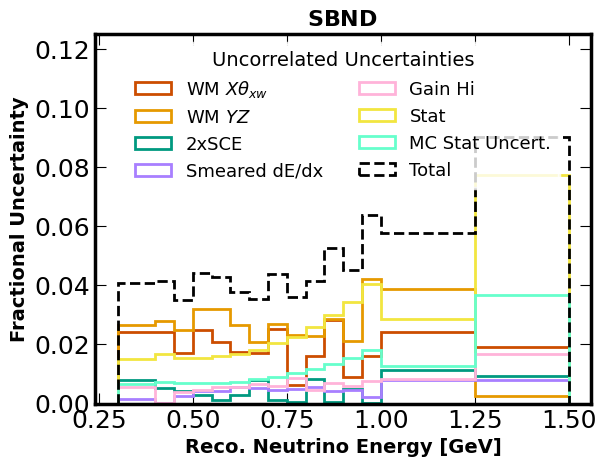

(array([0.0255506 , 0.02420339, 0.02320156, 0.02511198, 0.02407782,
        0.02424942, 0.02502415, 0.02740531, 0.02912678, 0.03196322,
        0.03238405, 0.03589016, 0.03864232, 0.02223216, 0.03660952]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7f33b3d45270>])

(0.0, 0.125)

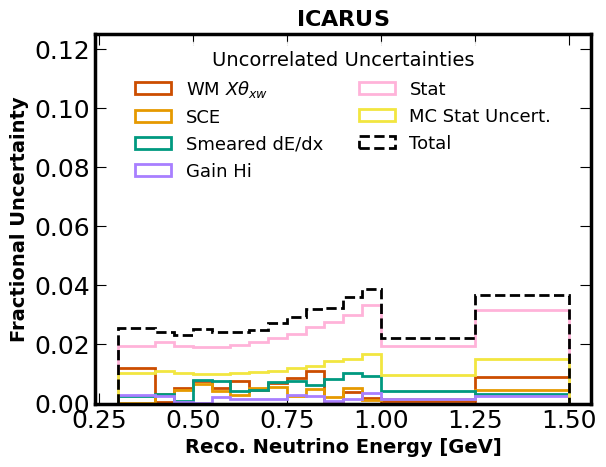

In [82]:
if CONFERENCE == False:
    plt.clf()
    S_detsyst_covs = [s.cov(var, cut, bins, SCV) for s in Ssystematics[labels.index("Detector/Uncorr.")].systs]
    I_detsyst_covs = [s.cov(var, cut, bins, ICV) for s in Isystematics[labels.index("Detector/Uncorr.")].systs]
    
    combined = np.zeros(Scovs[0].shape)
    for c, l in zip(S_detsyst_covs, SDETVAR_NAMES[1:] + SDETVAR_NAMES_SMALL[1:] + SCHI2_DETVAR_NAMES):
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)
        combined += c
        
    for c, l in zip(Scovs[4:], labels[4:len(labels)-1]):
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)
        combined += c
    
    plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(combined))/SCV), label="Total", histtype="step", color="black", linewidth=2, linestyle="--")
    
    add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
              legend_loc="upper center", legend_ncol=2, legend_title="Uncorrelated Uncertainties")
    
    plt.ylim([0, 0.125])
    plt.savefig(PLOTDIR + "png/SBND_signalbox_systematics_uncorr.png", bbox_inches="tight")
    plt.show()
    
    plt.clf()
    combined = np.zeros(Icovs[0].shape)
    for c, l in zip(I_detsyst_covs, IDETVAR_NAMES[1:] + ICHI2_DETVAR_NAMES):
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)
        combined += c
        
    for c, l in zip(Icovs[4:], labels[4:len(labels)-1]):
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)
        combined += c
    
    plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(combined))/ICV), label="Total", histtype="step", color="black", linewidth=2, linestyle="--")
    
    add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
              legend_loc="upper center", legend_ncol=2, legend_title="Uncorrelated Uncertainties")
    
    plt.ylim([0, 0.125])
    plt.savefig(PLOTDIR + "png/ICARUS_signalbox_systematics_uncorr.png", bbox_inches="tight")
    plt.show()

[354.64964532 263.05047215 269.81936086 254.68693725 221.66865939
 189.84809347 156.0007665  123.49479612 105.07193834  83.56206015
  62.94237425  48.50775084  36.9596327   88.85079523  16.46786182]
[1029.21515727  723.03020113  757.75585089  762.31918629  703.59627278
  661.87430026  540.4228949   419.26921078  357.71583004  265.23934046
  197.51447116  141.29018389   97.77850717  195.67863075   25.66525348]
[21.80658585 18.13842425 20.58419826 20.94761779 19.67966122 17.92080474
 14.98085382 12.04573687  9.81628759  7.39965858  5.54341513  4.21719879
  3.05855864  6.12683728  0.83354848]
[166.49572893 136.75538823 127.74761202 171.74053825 153.59412043
 118.00669044  87.87100492  90.61991787  51.32524711  44.52535661
  45.64587837  20.92172556  28.11023271  59.24180479   4.72023383]
[66.04026931 60.23026523 64.16260322 64.72652901 62.73700857 59.86786239
 54.73728861 49.08306606 44.3086619  38.46988063 33.29689213 29.04203434
 24.73280673 35.00524897 12.91161092]
[29.45849782 26.9011

Text(0.75, 0.25, 'SBN Analysis in Progress\nSBND Simulation')

(0.0001, 0.45)

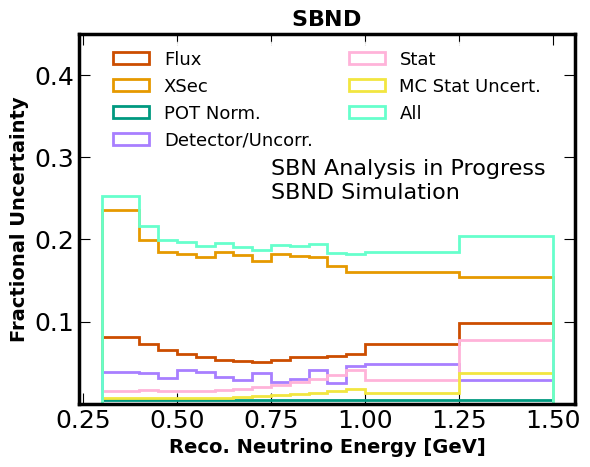

In [83]:
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')
for c, l in zip(Scovs, labels):
    # print(l)
    # if ((l != "Detector/Uncorr.") | (CONFERENCE == False)):
    #print(SCV)
    print(np.sqrt(np.diag(c)))
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2, dabadee=dbd)

plt_text = "SBN Analysis in Progress\nSBND Simulation"

if dbd:
    color='white'
else:
    color='black'

if CONFERENCE: 
    plt_text+="\nNo Detector Syst. Included"
plt.text(0.75, 0.25, plt_text, color=color, fontsize=FONTSIZE+2, zorder=10)
plt.ylim([0.0001, 0.45])

# plt.yscale("log")

plt.savefig(PLOTDIR + "png/SBND_signalbox_systematics.png", bbox_inches="tight")

Text(0.75, 0.25, 'SBN Analysis in Progress\nICARUS Simulation')

(0.0001, 0.45)

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/SBNDCM26Plots/png/ICARUS_signalbox_systematics.png


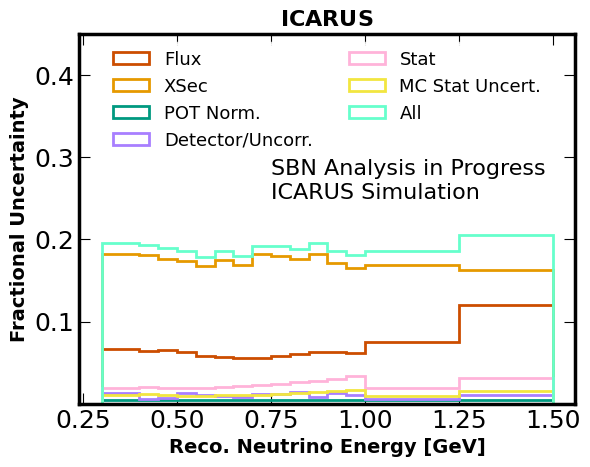

In [89]:
for c, l in zip(Icovs, labels):
    #if l != "Beam Off" and l != "Dirt" and ((l != "Detector/Uncorr.") | (CONFERENCE == False)):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2, dabadee=dbd)

plt_text = "SBN Analysis in Progress\nICARUS Simulation"

if dbd:
    color='white'
else:
    color='black'

if CONFERENCE: plt_text+="\nNo Detector Syst. Included"
plt.text(0.75, 0.25, plt_text, color=color, fontsize=FONTSIZE+2, zorder=10)
plt.ylim([0.0001, 0.45])
# plt.yscale("log")
print(PLOTDIR + "png/ICARUS_signalbox_systematics.png")
plt.savefig(PLOTDIR + "png/ICARUS_signalbox_systematics.png", bbox_inches="tight")

In [90]:
covs = [s.cov(var, cut, bins, np.concatenate((SCV, ICV))) for s in systematics]
covs.append(np.diag(np.concatenate((SCV, ICV))))
covs.append(np.diag(np.concatenate((wSCVsq, wICVsq))))

In [91]:
def ratio_cov_full(x, y, cov):
    """
    Covariance of r = x / y given the full covariance of (x, y).

    Parameters
    ----------
    x, y : array-like, shape (n,)
        Central values
    cov : array-like, shape (2n, 2n)
        Full covariance matrix of (x, y)

        Ordering must be:
        cov = [[Cov(x,x), Cov(x,y)],
               [Cov(y,x), Cov(y,y)]]

    Returns
    -------
    cov_r : ndarray, shape (n, n)
        Covariance matrix of r
    """
    n = len(x)
    assert cov.shape == (2*n, 2*n)

    # Protect against division by zero
    eps = 1e-12
    y_safe = np.where(np.abs(y) < eps, eps, y)

    Dx = np.diag(1.0 / y_safe)
    Dy = np.diag(-x / y_safe**2)

    # Full Jacobian: shape (n, 2n)
    J = np.hstack([Dx, Dy])

    return J @ cov @ J.T

In [92]:
ratio = SCV / ICV
ratio_cov_flux = ratio_cov_full(SCV, ICV, covs[0])
ratio_cov_xsec = ratio_cov_full(SCV, ICV, covs[1])
ratio_cov_norm = ratio_cov_full(SCV, ICV, covs[2])
ratio_cov_det = ratio_cov_full(SCV, ICV, covs[3])
ratio_cov_stat = ratio_cov_full(SCV, ICV, covs[4])
ratio_cov_mcstat = ratio_cov_full(SCV, ICV, covs[5])

ratio_cov_all = ratio_cov_full(SCV, ICV, np.sum(covs, axis=0))

Text(0.7, 0.1, 'SBN Analysis in Progress\nSBN Simulation')

(0.0001, 0.23)

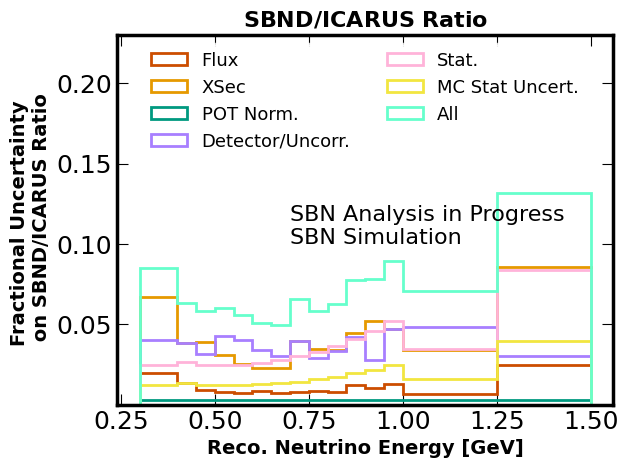

In [93]:
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_flux))/ratio, histtype="step", linewidth=2, label="Flux")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_xsec))/ratio, histtype="step", linewidth=2, label="XSec")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_norm))/ratio, histtype="step", linewidth=2, label="POT Norm.")
if (CONFERENCE == False):
    _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_det))/ratio, histtype="step", linewidth=2, label="Detector/Uncorr.")
elif (CONFERENCE == True):
    _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_det))/ratio, histtype="step", linewidth=2, label="Dirt")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_stat))/ratio, histtype="step", linewidth=2, label="Stat.")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_mcstat))/ratio, histtype="step", linewidth=2, label="MC Stat Uncert.")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_all))/ratio, histtype="step", linewidth=2, label="All")
# plt.ylim([0, 0.25])

if dbd:
    color='white'
else:
    color='black'
    
add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", title="Ratio", det="SBND / ICARUS", 
          ylabel="Fractional Uncertainty \n on SBND/ICARUS Ratio", legend_loc="upper center", legend_ncol=2, dabadee=dbd)

plt_text = "SBN Analysis in Progress\nSBN Simulation"
if CONFERENCE: plt_text+="\nNo Detector Syst. Included"
plt.text(0.7, 0.1, plt_text, color=color, fontsize=FONTSIZE+2)
plt.ylim([0.0001, 0.23])

plt.savefig(PLOTDIR + "png/ratio_signalbox_systematics.png", bbox_inches="tight")